In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("df_cleaned.csv")

In [2]:
df.columns

Index(['id', 'is_weekend', 'day_in_study', 'phase', 'lh', 'estrogen',
       'flow_color', 'calories_daily', 'steps_daily', 'bpm_mean', 'bpm_min',
       'bpm_max', 'bpm_std', 'temp_diff_from_baseline_mean',
       'temp_diff_from_baseline_min', 'temp_diff_from_baseline_max',
       'temp_diff_from_baseline_std', 'glucose_mean', 'glucose_min',
       'glucose_max', 'glucose_std', 'overall_score', 'composition_score',
       'revitalization_score', 'duration_score', 'nightly_temperature',
       'duration', 'minutestofallasleep', 'minutesasleep', 'minutesawake',
       'minutesafterwakeup', 'timeinbed', 'efficiency', 'duration_exercise',
       'calories_exercise', 'heartrate_exercise', 'activity_type',
       'in_default_zone_3', 'in_default_zone_2', 'in_default_zone_1',
       'below_default_zone_1', 'birth_year', 'gender', 'ethnicity',
       'education', 'sexually_active', 'self_report_menstrual_health_literacy',
       'age_of_first_menarche', 'flow_volume_score', 'appetite_score',

FEATURE SELECTION FOR PHASE PREDICTION
Total features: 59
Samples: 2970
Target classes: [0 1 2 3]


1. RANDOM FOREST FEATURE IMPORTANCE
------------------------------------------------------------

Top 15 features by Random Forest:
                     feature  importance
                  flow_color    0.060535
                          lh    0.060454
           flow_volume_score    0.051591
                    estrogen    0.042463
         nightly_temperature    0.039043
                day_in_study    0.035786
 temp_diff_from_baseline_max    0.032712
                    bpm_mean    0.025398
temp_diff_from_baseline_mean    0.024560
                glucose_mean    0.024526
                     bpm_min    0.024124
           in_default_zone_1    0.023365
 temp_diff_from_baseline_std    0.022961
 temp_diff_from_baseline_min    0.022846
                     bpm_std    0.022148


2. MUTUAL INFORMATION
------------------------------------------------------------

Top 15 features by Mutual 

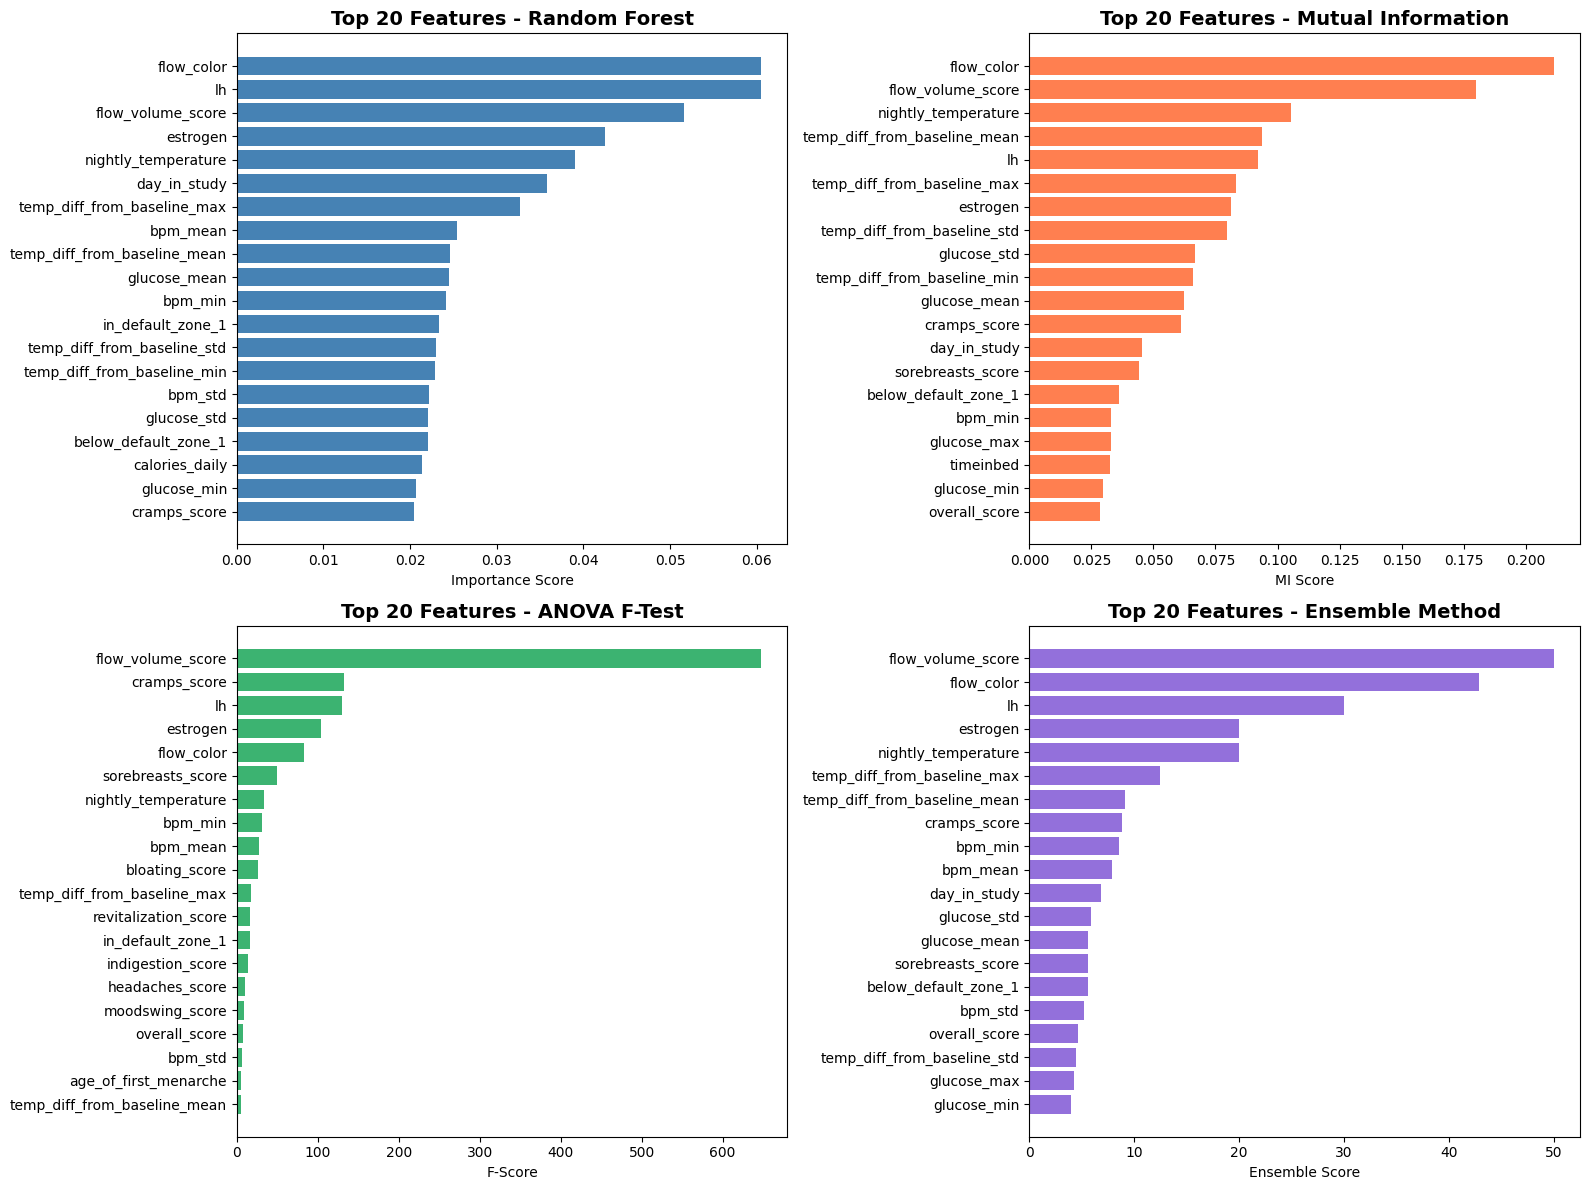

In [3]:
# Define target and features
target = 'phase'
exclude_cols = ['id', 'phase']  # Exclude ID and target

# Get feature columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Prepare data
X = df[feature_cols].copy()
y = df[target].copy()

# Handle categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Handle missing values
X = X.fillna(X.median())

# Encode target if categorical
if y.dtype == 'object':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)

print("=" * 60)
print("FEATURE SELECTION FOR PHASE PREDICTION")
print("=" * 60)
print(f"Total features: {len(feature_cols)}")
print(f"Samples: {len(df)}")
print(f"Target classes: {np.unique(y)}")
print()

# ============================================================================
# METHOD 1: Random Forest Feature Importance
# ============================================================================
print("\n1. RANDOM FOREST FEATURE IMPORTANCE")
print("-" * 60)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 features by Random Forest:")
print(rf_importance.head(15).to_string(index=False))

# ============================================================================
# METHOD 2: Mutual Information
# ============================================================================
print("\n\n2. MUTUAL INFORMATION")
print("-" * 60)

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_importance = pd.DataFrame({
    'feature': feature_cols,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nTop 15 features by Mutual Information:")
print(mi_importance.head(15).to_string(index=False))

# ============================================================================
# METHOD 3: ANOVA F-statistic
# ============================================================================
print("\n\n3. ANOVA F-STATISTIC")
print("-" * 60)

f_scores, p_values = f_classif(X, y)
anova_importance = pd.DataFrame({
    'feature': feature_cols,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('f_score', ascending=False)

print("\nTop 15 features by ANOVA F-score:")
print(anova_importance.head(15).to_string(index=False))

# ============================================================================
# ENSEMBLE RANKING: Combine all methods
# ============================================================================
print("\n\n4. ENSEMBLE RANKING (Combined Methods)")
print("-" * 60)

# Create rank for each method
rf_importance['rf_rank'] = rf_importance['importance'].rank(ascending=False)
mi_importance['mi_rank'] = mi_importance['mi_score'].rank(ascending=False)
anova_importance['anova_rank'] = anova_importance['f_score'].rank(ascending=False)

# Merge all rankings
ensemble = rf_importance[['feature', 'rf_rank']].merge(
    mi_importance[['feature', 'mi_rank']], on='feature'
).merge(
    anova_importance[['feature', 'anova_rank']], on='feature'
)

ensemble['avg_rank'] = ensemble[['rf_rank', 'mi_rank', 'anova_rank']].mean(axis=1)

ensemble = ensemble.sort_values('avg_rank')
ensemble['ensemble_score'] = 100 / ensemble['avg_rank']

print("\nTop 20 features by Ensemble Ranking:")
print(ensemble.head(20).to_string(index=False))

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n\nGenerating visualizations...")

# Plot 1: Top 20 features by Random Forest
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

top_n = 20

# Random Forest
ax1 = axes[0, 0]
top_rf = rf_importance.head(top_n)
ax1.barh(range(len(top_rf)), top_rf['importance'], color='steelblue')
ax1.set_yticks(range(len(top_rf)))
ax1.set_yticklabels(top_rf['feature'])
ax1.set_xlabel('Importance Score')
ax1.set_title('Top 20 Features - Random Forest', fontsize=14, fontweight='bold')
ax1.invert_yaxis()

# Mutual Information
ax2 = axes[0, 1]
top_mi = mi_importance.head(top_n)
ax2.barh(range(len(top_mi)), top_mi['mi_score'], color='coral')
ax2.set_yticks(range(len(top_mi)))
ax2.set_yticklabels(top_mi['feature'])
ax2.set_xlabel('MI Score')
ax2.set_title('Top 20 Features - Mutual Information', fontsize=14, fontweight='bold')
ax2.invert_yaxis()

# ANOVA F-statistic
ax3 = axes[1, 0]
top_anova = anova_importance.head(top_n)
ax3.barh(range(len(top_anova)), top_anova['f_score'], color='mediumseagreen')
ax3.set_yticks(range(len(top_anova)))
ax3.set_yticklabels(top_anova['feature'])
ax3.set_xlabel('F-Score')
ax3.set_title('Top 20 Features - ANOVA F-Test', fontsize=14, fontweight='bold')
ax3.invert_yaxis()

# Ensemble
ax4 = axes[1, 1]
top_ensemble = ensemble.head(top_n)
ax4.barh(range(len(top_ensemble)), top_ensemble['ensemble_score'], color='mediumpurple')
ax4.set_yticks(range(len(top_ensemble)))
ax4.set_yticklabels(top_ensemble['feature'])
ax4.set_xlabel('Ensemble Score')
ax4.set_title('Top 20 Features - Ensemble Method', fontsize=14, fontweight='bold')
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: feature_importance_comparison.png")


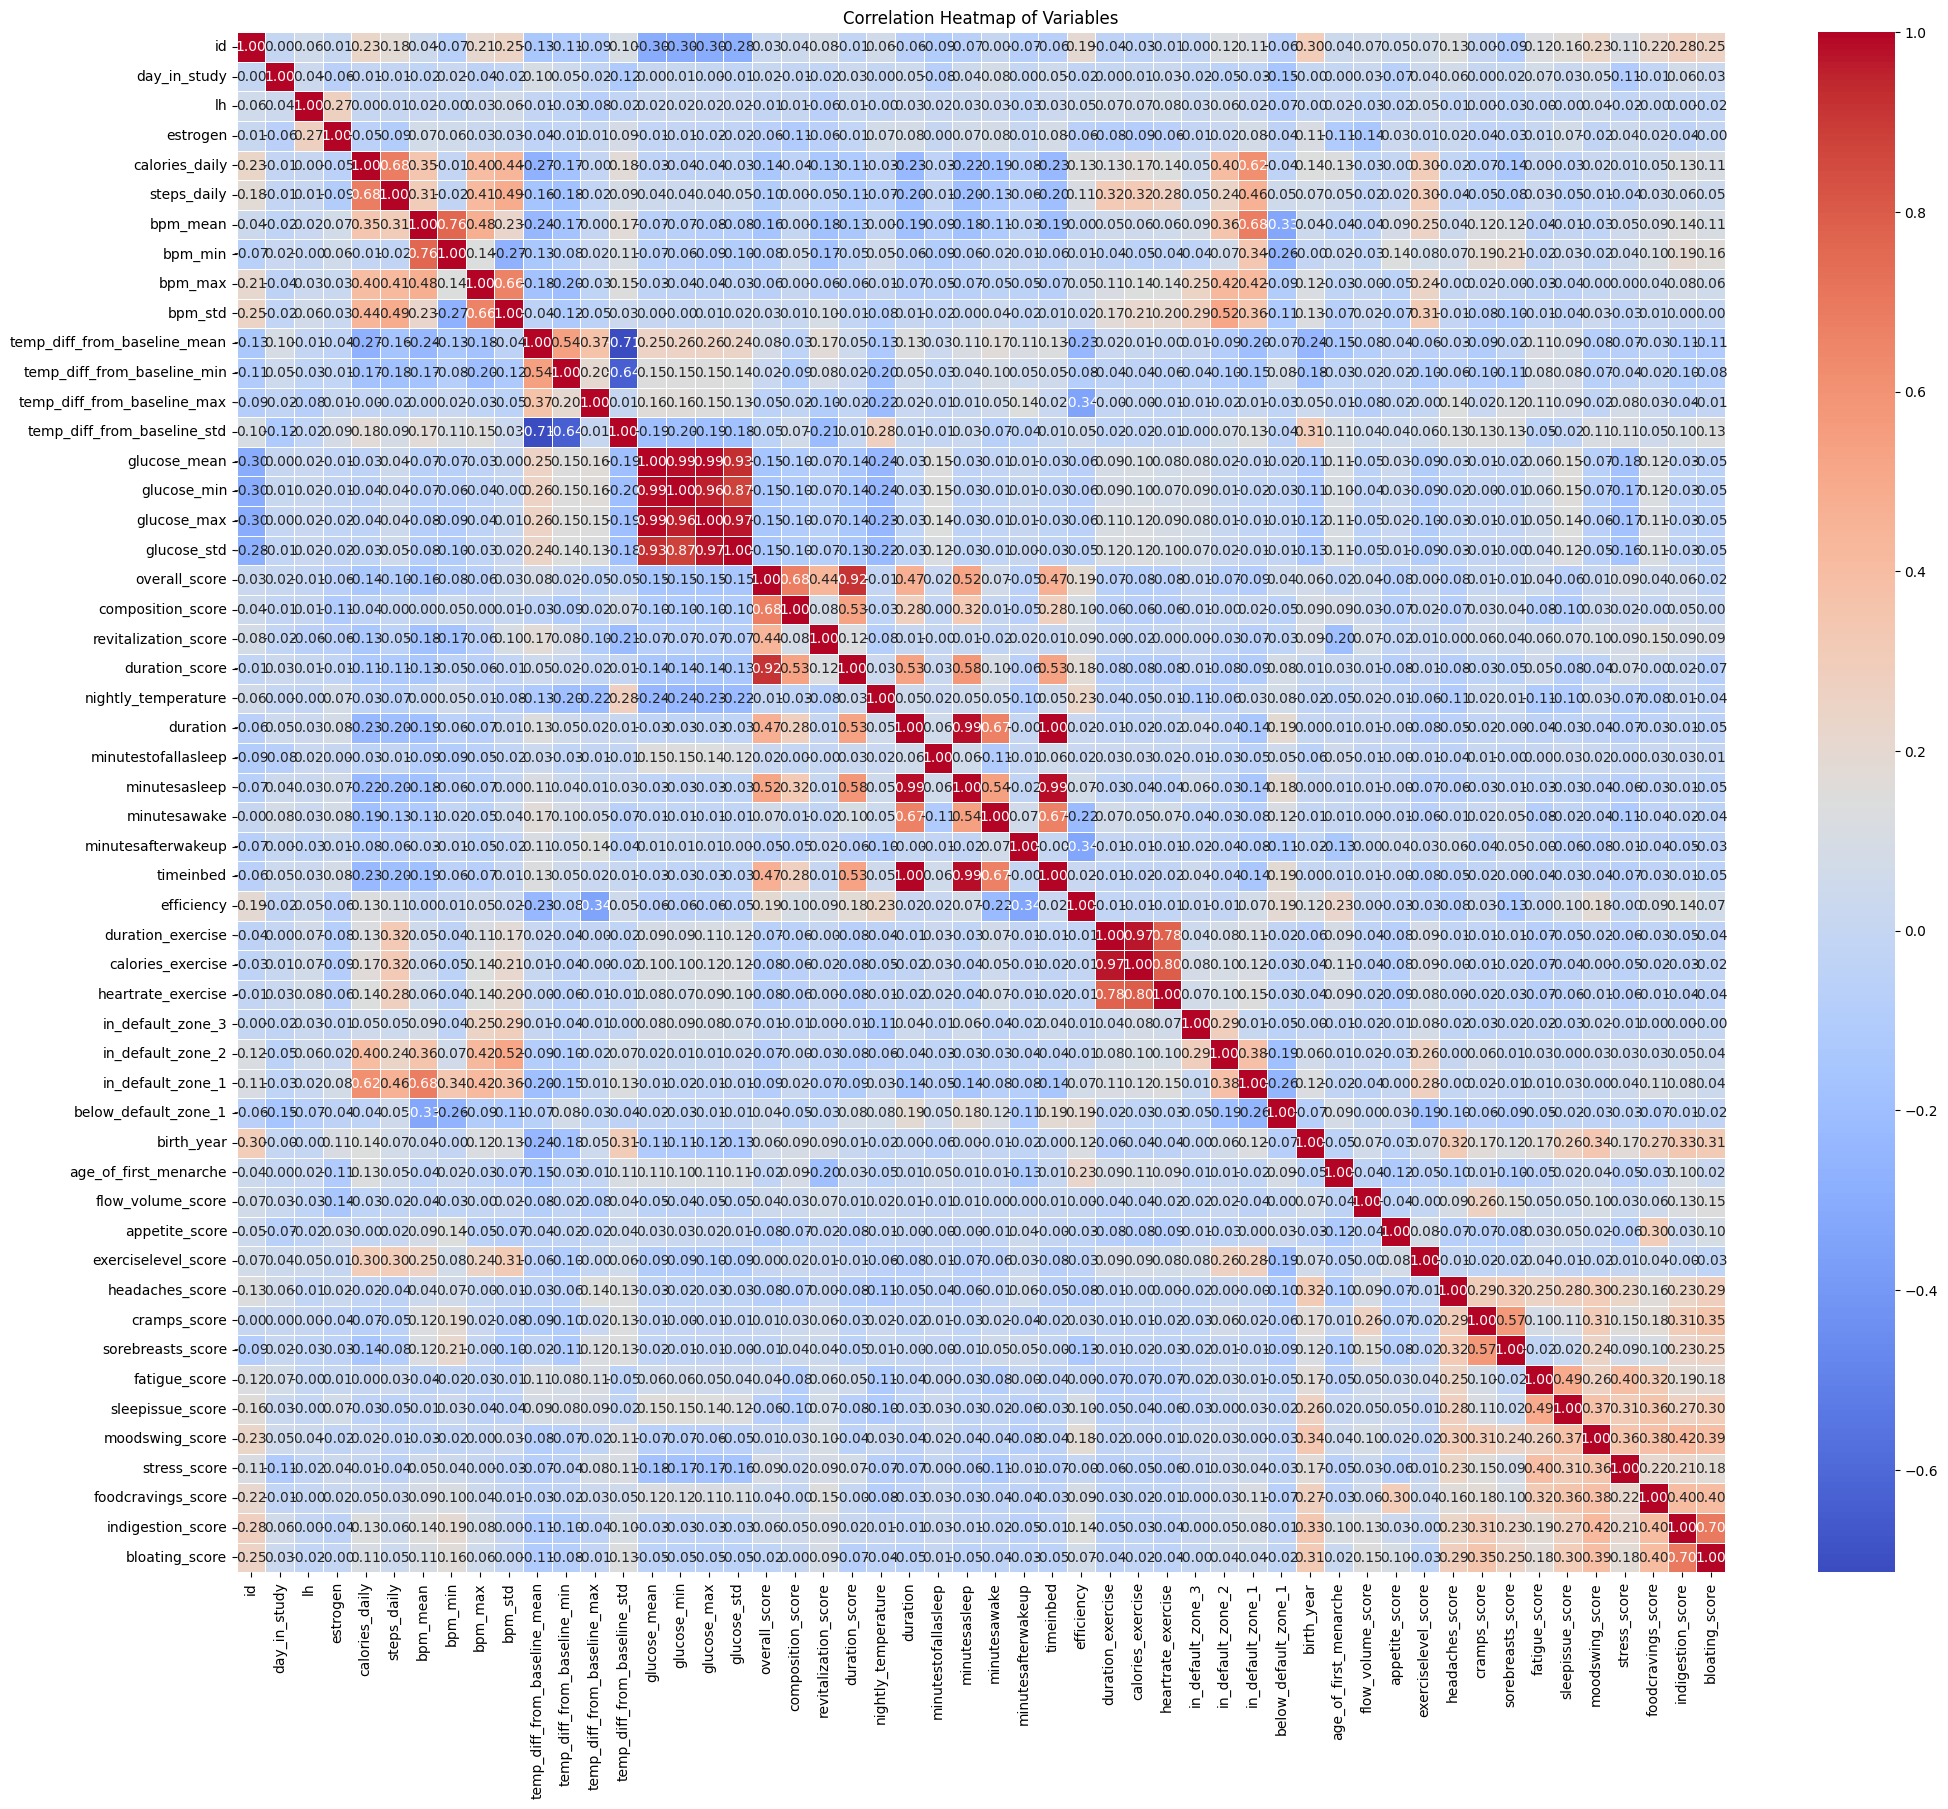

In [4]:
plt.figure(figsize=(24, 20)) # Adjust figure size as needed
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5)

plt.title('Correlation Heatmap of Variables')
plt.show()


In [5]:
# Number of features you want
top_n = 30

# Get list of top features
top_features = ensemble.head(top_n)['feature'].tolist()

# Create a new dataframe with only the top features + target
df_selected = df[top_features + [target]].copy()

df_selected.columns

Index(['flow_volume_score', 'flow_color', 'lh', 'estrogen',
       'nightly_temperature', 'temp_diff_from_baseline_max',
       'temp_diff_from_baseline_mean', 'cramps_score', 'bpm_min', 'bpm_mean',
       'day_in_study', 'glucose_std', 'glucose_mean', 'sorebreasts_score',
       'below_default_zone_1', 'bpm_std', 'overall_score',
       'temp_diff_from_baseline_std', 'glucose_max', 'glucose_min',
       'in_default_zone_1', 'age_of_first_menarche', 'bloating_score',
       'temp_diff_from_baseline_min', 'calories_daily', 'indigestion_score',
       'composition_score', 'timeinbed', 'revitalization_score',
       'duration_score', 'phase'],
      dtype='object')

FEATURE SELECTION FOR PHASE PREDICTION
Total features: 59
Samples: 2970
Target classes: [0 1 2 3]


1. RANDOM FOREST FEATURE IMPORTANCE
------------------------------------------------------------

Top 15 features by Random Forest:
                     feature  importance
                  flow_color    0.060535
                          lh    0.060454
           flow_volume_score    0.051591
                    estrogen    0.042463
         nightly_temperature    0.039043
                day_in_study    0.035786
 temp_diff_from_baseline_max    0.032712
                    bpm_mean    0.025398
temp_diff_from_baseline_mean    0.024560
                glucose_mean    0.024526
                     bpm_min    0.024124
           in_default_zone_1    0.023365
 temp_diff_from_baseline_std    0.022961
 temp_diff_from_baseline_min    0.022846
                     bpm_std    0.022148


2. MUTUAL INFORMATION
------------------------------------------------------------

Top 15 features by Mutual 

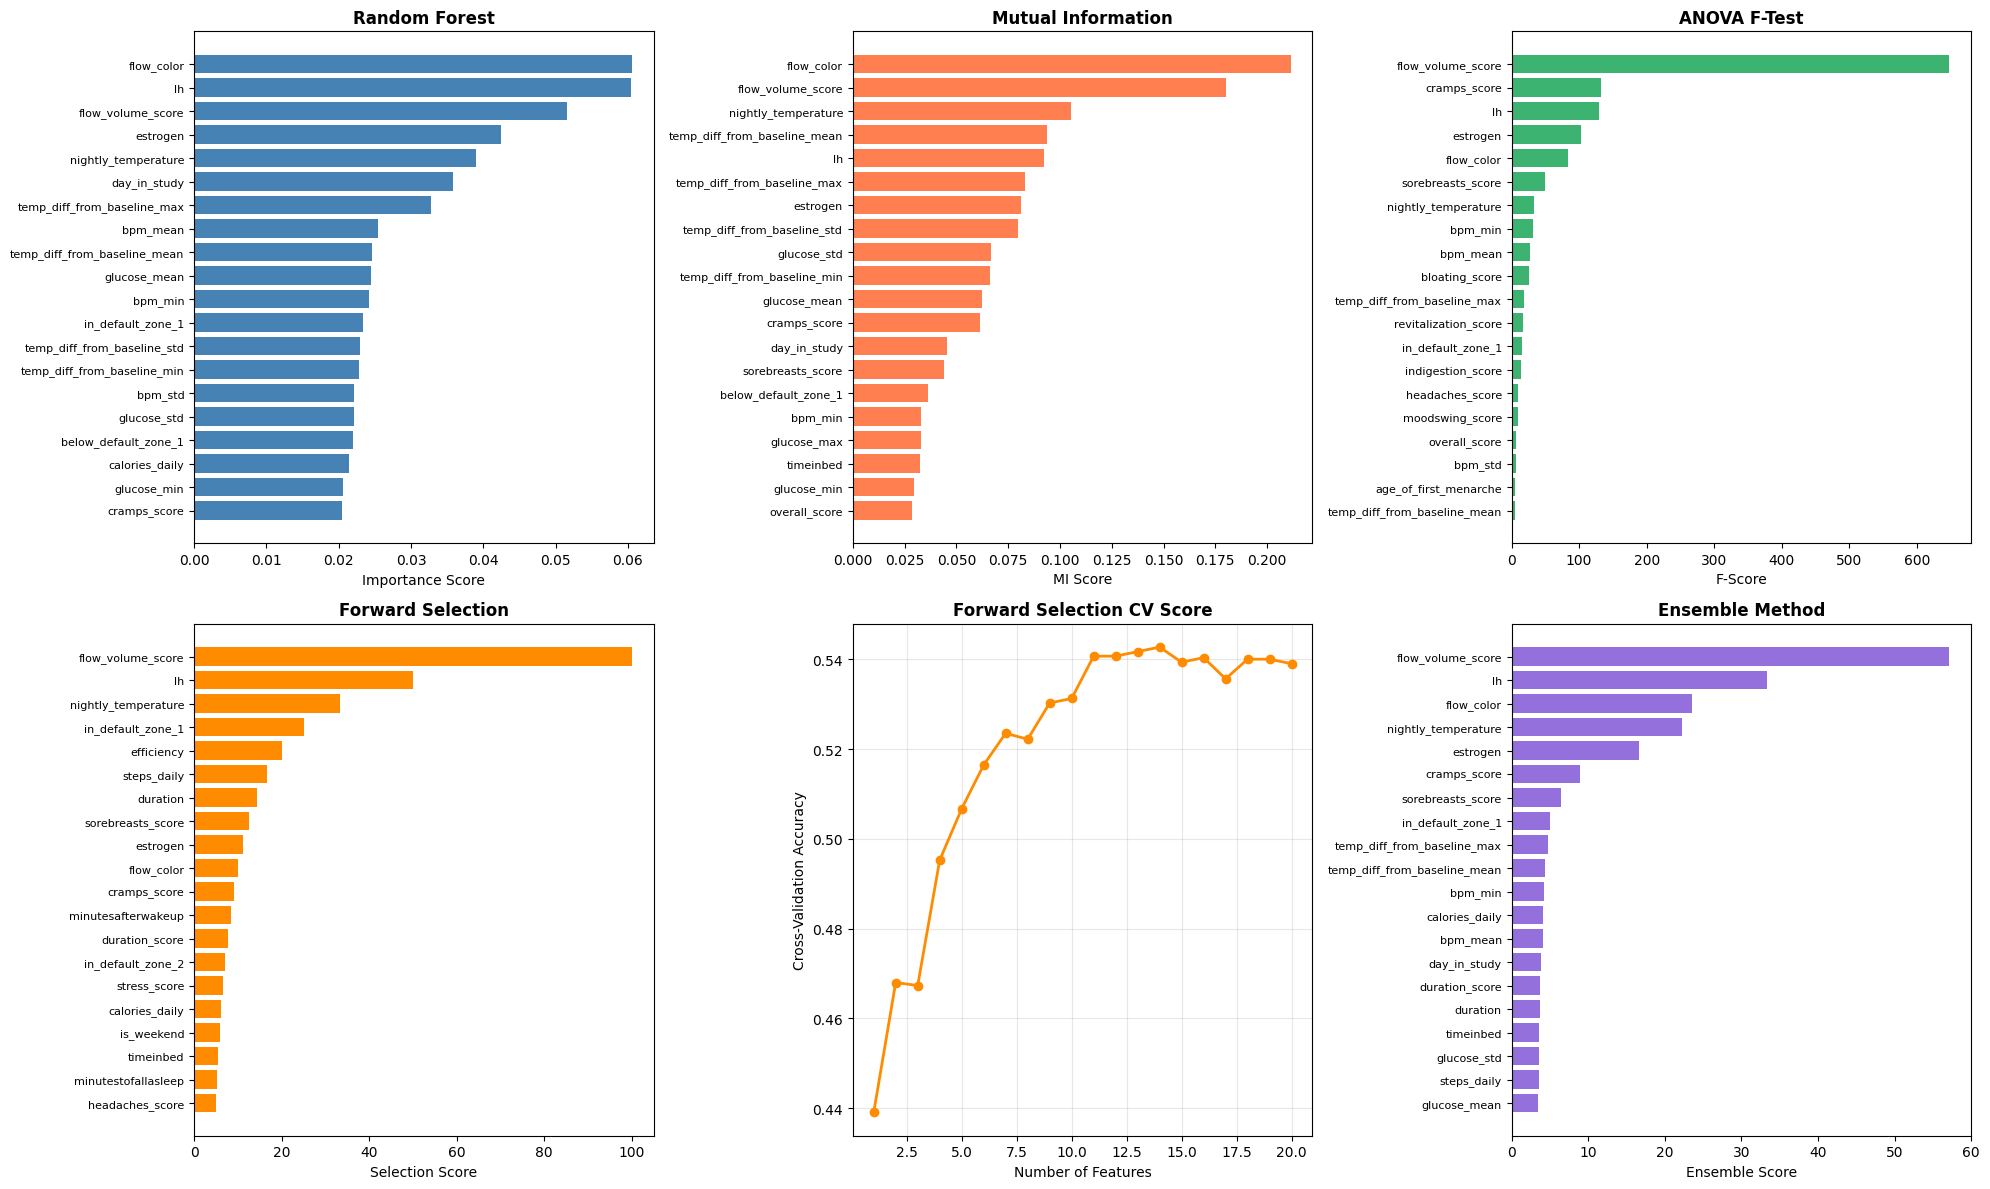

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define target and features
target = 'phase'
exclude_cols = ['id', 'phase']

# Get feature columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Prepare data
X = df[feature_cols].copy()
y = df[target].copy()

# Handle categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Handle missing values
X = X.fillna(X.median())

# Encode target if categorical
if y.dtype == 'object':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)

print("=" * 60)
print("FEATURE SELECTION FOR PHASE PREDICTION")
print("=" * 60)
print(f"Total features: {len(feature_cols)}")
print(f"Samples: {len(df)}")
print(f"Target classes: {np.unique(y)}")
print()

# ============================================================================
# METHOD 1: Random Forest Feature Importance
# ============================================================================
print("\n1. RANDOM FOREST FEATURE IMPORTANCE")
print("-" * 60)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 features by Random Forest:")
print(rf_importance.head(15).to_string(index=False))

# ============================================================================
# METHOD 2: Mutual Information
# ============================================================================
print("\n\n2. MUTUAL INFORMATION")
print("-" * 60)

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_importance = pd.DataFrame({
    'feature': feature_cols,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nTop 15 features by Mutual Information:")
print(mi_importance.head(15).to_string(index=False))

# ============================================================================
# METHOD 3: ANOVA F-statistic
# ============================================================================
print("\n\n3. ANOVA F-STATISTIC")
print("-" * 60)

f_scores, p_values = f_classif(X, y)
anova_importance = pd.DataFrame({
    'feature': feature_cols,
    'f_score': f_scores,
    'p_value': p_values
}).sort_values('f_score', ascending=False)

print("\nTop 15 features by ANOVA F-score:")
print(anova_importance.head(15).to_string(index=False))

# ============================================================================
# METHOD 4: Forward Selection
# ============================================================================
print("\n\n4. FORWARD SELECTION")
print("-" * 60)

def forward_selection(X, y, max_features=20, cv=5):
    """
    Perform forward feature selection using cross-validation.
    
    Parameters:
    - X: Feature matrix
    - y: Target vector
    - max_features: Maximum number of features to select
    - cv: Number of cross-validation folds
    
    Returns:
    - selected_features: List of selected feature names in order
    - scores_history: CV scores at each step
    """
    remaining_features = list(X.columns)
    selected_features = []
    scores_history = []
    
    print(f"Starting forward selection (max {max_features} features, {cv}-fold CV)...")
    print()
    
    for step in range(max_features):
        best_score = -np.inf
        best_feature = None
        
        # Try adding each remaining feature
        for feature in remaining_features:
            current_features = selected_features + [feature]
            X_subset = X[current_features]
            
            # Use Random Forest for evaluation
            model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
            score = cross_val_score(model, X_subset, y, cv=cv, scoring='accuracy').mean()
            
            if score > best_score:
                best_score = score
                best_feature = feature
        
        # Add best feature
        if best_feature:
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
            scores_history.append(best_score)
            
            print(f"Step {step + 1}: Added '{best_feature}' | CV Score: {best_score:.4f}")
        else:
            break
    
    return selected_features, scores_history

# Run forward selection
selected_features, cv_scores = forward_selection(X, y, max_features=20, cv=5)

# Create importance dataframe
forward_importance = pd.DataFrame({
    'feature': selected_features,
    'selection_order': range(1, len(selected_features) + 1),
    'cv_score_when_added': cv_scores,
    'forward_score': [100 / i for i in range(1, len(selected_features) + 1)]
})

print("\n\nForward Selection Results:")
print(forward_importance.to_string(index=False))

# ============================================================================
# ENSEMBLE RANKING: Combine all methods
# ============================================================================
print("\n\n5. ENSEMBLE RANKING (Combined Methods)")
print("-" * 60)

# Create rank for each method
rf_importance['rf_rank'] = rf_importance['importance'].rank(ascending=False)
mi_importance['mi_rank'] = mi_importance['mi_score'].rank(ascending=False)
anova_importance['anova_rank'] = anova_importance['f_score'].rank(ascending=False)

# Add forward selection rank
forward_rank = forward_importance[['feature', 'selection_order']].copy()
forward_rank.columns = ['feature', 'forward_rank']

# Merge all rankings
ensemble = rf_importance[['feature', 'rf_rank']].merge(
    mi_importance[['feature', 'mi_rank']], on='feature'
).merge(
    anova_importance[['feature', 'anova_rank']], on='feature'
).merge(
    forward_rank, on='feature', how='left'
)

# Fill NaN for features not selected by forward selection with max rank + 1
ensemble['forward_rank'] = ensemble['forward_rank'].fillna(len(feature_cols) + 1)

# Calculate average rank including forward selection
ensemble['avg_rank'] = ensemble[['rf_rank', 'mi_rank', 'anova_rank', 'forward_rank']].mean(axis=1)
ensemble = ensemble.sort_values('avg_rank')
ensemble['ensemble_score'] = 100 / ensemble['avg_rank']

print("\nTop 20 features by Ensemble Ranking (including Forward Selection):")
print(ensemble.head(20).to_string(index=False))

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n\nGenerating visualizations...")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
top_n = 20

# Random Forest
ax1 = axes[0, 0]
top_rf = rf_importance.head(top_n)
ax1.barh(range(len(top_rf)), top_rf['importance'], color='steelblue')
ax1.set_yticks(range(len(top_rf)))
ax1.set_yticklabels(top_rf['feature'], fontsize=8)
ax1.set_xlabel('Importance Score')
ax1.set_title('Random Forest', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Mutual Information
ax2 = axes[0, 1]
top_mi = mi_importance.head(top_n)
ax2.barh(range(len(top_mi)), top_mi['mi_score'], color='coral')
ax2.set_yticks(range(len(top_mi)))
ax2.set_yticklabels(top_mi['feature'], fontsize=8)
ax2.set_xlabel('MI Score')
ax2.set_title('Mutual Information', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

# ANOVA F-statistic
ax3 = axes[0, 2]
top_anova = anova_importance.head(top_n)
ax3.barh(range(len(top_anova)), top_anova['f_score'], color='mediumseagreen')
ax3.set_yticks(range(len(top_anova)))
ax3.set_yticklabels(top_anova['feature'], fontsize=8)
ax3.set_xlabel('F-Score')
ax3.set_title('ANOVA F-Test', fontsize=12, fontweight='bold')
ax3.invert_yaxis()

# Forward Selection - Feature order
ax4 = axes[1, 0]
ax4.barh(range(len(forward_importance)), forward_importance['forward_score'], color='darkorange')
ax4.set_yticks(range(len(forward_importance)))
ax4.set_yticklabels(forward_importance['feature'], fontsize=8)
ax4.set_xlabel('Selection Score')
ax4.set_title('Forward Selection', fontsize=12, fontweight='bold')
ax4.invert_yaxis()

# Forward Selection - CV Score progression
ax5 = axes[1, 1]
ax5.plot(range(1, len(cv_scores) + 1), cv_scores, marker='o', linewidth=2, markersize=6, color='darkorange')
ax5.set_xlabel('Number of Features')
ax5.set_ylabel('Cross-Validation Accuracy')
ax5.set_title('Forward Selection CV Score', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Ensemble
ax6 = axes[1, 2]
top_ensemble = ensemble.head(top_n)
ax6.barh(range(len(top_ensemble)), top_ensemble['ensemble_score'], color='mediumpurple')
ax6.set_yticks(range(len(top_ensemble)))
ax6.set_yticklabels(top_ensemble['feature'], fontsize=8)
ax6.set_xlabel('Ensemble Score')
ax6.set_title('Ensemble Method', fontsize=12, fontweight='bold')
ax6.invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: feature_importance_comparison.png")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

# Find features that appear in top 10 of all methods
top_10_rf = set(rf_importance.head(10)['feature'])
top_10_mi = set(mi_importance.head(10)['feature'])
top_10_anova = set(anova_importance.head(10)['feature'])
top_10_forward = set(forward_importance.head(10)['feature'])

consensus_features = top_10_rf & top_10_mi & top_10_anova & top_10_forward

print(f"\nFeatures in top 10 of ALL methods: {len(consensus_features)}")
if consensus_features:
    print("These high-consensus features are:")
    for feat in consensus_features:
        print(f"  - {feat}")

print(f"\nBest CV accuracy with forward selection: {max(cv_scores):.4f}")
print(f"Achieved with {cv_scores.index(max(cv_scores)) + 1} features")

In [7]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


## Preprocessing

In [8]:
target = "phase"
X = df.drop(columns=[target])
y = df[target]

numeric_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object','category']).columns

preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy='mean')),
        ("scaler", StandardScaler())
    ]), numeric_cols),
    
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy='most_frequent')),
        ("onehot", OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])


## K-Best

In [9]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

kbest = Pipeline([
    ("prep", preprocess),
    ("select", SelectKBest(score_func=f_classif, k=10))
])

kbest.fit(X, y)

kbest_features = kbest.named_steps["select"].get_support()
feature_names = kbest.named_steps["prep"].get_feature_names_out()
print("K-Best features：")
print(feature_names[kbest_features])


K-Best features：
['num__lh' 'num__estrogen' 'num__bpm_min' 'num__nightly_temperature'
 'num__flow_volume_score' 'num__cramps_score' 'num__sorebreasts_score'
 'cat__flow_color_Bright Red' 'cat__flow_color_Dark Brown / Dark Red'
 'cat__flow_color_Not at all']


## RFECV

In [10]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

rfecv = Pipeline([
    ("prep", preprocess),
    ("select", RFECV(
        estimator=LogisticRegression(max_iter=2000),
        scoring="accuracy",
        cv=5
    ))
])

rfecv.fit(X, y)

rfe_features = rfecv.named_steps["select"].support_
feature_names = rfecv.named_steps["prep"].get_feature_names_out()
print("RFECV features：")
print(feature_names[rfe_features])


RFECV features：
['num__lh' 'num__glucose_mean' 'num__glucose_max' 'num__flow_volume_score'
 'num__cramps_score' 'cat__flow_color_Bright Red'
 'cat__flow_color_Dark Brown / Dark Red' 'cat__flow_color_Not at all'
 'cat__flow_color_Other' 'cat__flow_color_Pink' 'cat__flow_color_Yellow'
 'cat__activity_type_Outdoor Bike' 'cat__activity_type_Run'
 'cat__gender_Gender Fluid' 'cat__gender_Non-binary' 'cat__gender_Woman'
 'cat__self_report_menstrual_health_literacy_Expert']


## Forward

In [11]:
!pip install mlxtend



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [12]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

# Forward
sfs_forward = Pipeline([
    ("prep", preprocess),
    ("select", SequentialFeatureSelector(
        model,
        k_features="best",
        forward=True,
        scoring="accuracy",
        cv=5
    ))
])

sfs_forward.fit(X, y)

forward_idx = sfs_forward.named_steps["select"].k_feature_idx_
feature_names = sfs_forward.named_steps["prep"].get_feature_names_out()
print("Forward features：")
print(feature_names[list(forward_idx)])


Forward features：
['num__day_in_study' 'num__lh' 'num__estrogen' 'num__calories_daily'
 'num__temp_diff_from_baseline_max' 'num__glucose_mean' 'num__glucose_std'
 'num__revitalization_score' 'num__minutestofallasleep'
 'num__minutesasleep' 'num__minutesafterwakeup' 'num__duration_exercise'
 'num__calories_exercise' 'num__heartrate_exercise'
 'num__in_default_zone_3' 'num__in_default_zone_2'
 'num__flow_volume_score' 'num__appetite_score' 'num__cramps_score'
 'num__sorebreasts_score' 'num__fatigue_score' 'num__sleepissue_score'
 'num__foodcravings_score' 'cat__flow_color_Black'
 'cat__flow_color_Bright Red' 'cat__flow_color_Dark Brown / Dark Red'
 'cat__flow_color_Grey' 'cat__flow_color_Not at all'
 'cat__flow_color_Orange' 'cat__flow_color_Other' 'cat__flow_color_Pink'
 'cat__flow_color_Yellow' 'cat__activity_type_Aerobic Workout'
 'cat__activity_type_Elliptical' 'cat__activity_type_No Exercise'
 'cat__activity_type_Outdoor Bike' 'cat__activity_type_Run'
 'cat__activity_type_Sport' 'ca

## Backward

In [13]:
# Backward
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier
sfs_backward = Pipeline([
    ("prep", preprocess),
    ("select", SequentialFeatureSelector(
        model,
        k_features="best",
        forward=False,
        scoring="accuracy",
        cv=5
    ))
])

sfs_backward.fit(X, y)

backward_idx = sfs_backward.named_steps["select"].k_feature_idx_
feature_names = sfs_backward.named_steps["prep"].get_feature_names_out()
print("Backward features：")
print(feature_names[list(backward_idx)])


Backward features：
['num__lh' 'num__estrogen' 'num__bpm_mean' 'num__bpm_min'
 'num__temp_diff_from_baseline_max' 'num__nightly_temperature'
 'num__efficiency' 'num__in_default_zone_2' 'num__below_default_zone_1'
 'num__age_of_first_menarche' 'num__flow_volume_score'
 'num__exerciselevel_score' 'num__cramps_score' 'num__sorebreasts_score'
 'cat__flow_color_Yellow']
